## 0. Interpreter와 Notebook Kernel이 다르면 터미널에서는 설치된 패키지가 Notebook에서 보이지 않는 문제가 생길 수 있습니다.
### 실행 코드

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn import set_config


set_config(display="text")
print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Current working directory:", Path.cwd())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Python executable: c:\Dev\llm-data-analysis\.venv\Scripts\python.exe
Python version: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
Current working directory: c:\Dev\llm-data-analysis\notebooks
pandas: 3.0.5
numpy: 2.5.3


기본 라이브러리 실행 오류 여부 확인

현재 Python:3.14.6

현재 Notebook Kernel: 3.14.6

현재 작업 폴더: c:\Dev\llm-data-analysis\notebooks

확인한 패키지:

환경에서 추가로 확인할 점:

## STEP 02. Titanic 데이터 확보와 로딩
### 02-1프로젝트 루트 찾기

In [2]:

from pathlib import Path
def get_project_root(start_path: Path | None = None) -> Path:
    """현재 위치에서 상위 폴더를 탐색해 data 폴더가 있는 프로젝트 루트를 찾는다."""
    current = (start_path or Path.cwd()).resolve()
    for path in (current, *current.parents):
        if (path / "data").is_dir():
            return path
    raise FileNotFoundError("data 폴더가 있는 프로젝트 루트를 찾을 수 없습니다.")
project_root = get_project_root()

data_path = project_root / "data" / "titanic" / "train.csv"

if not data_path.exists():
    raise FileNotFoundError(
        f"Titanic 데이터가 없습니다: {data_path}\n"
        "저장소 루트에서 python scripts/prepare_titanic_data.py 를 먼저 실행하세요."
    )

print(project_root)
print(data_path)

C:\Dev\llm-data-analysis
C:\Dev\llm-data-analysis\data\titanic\train.csv


프로젝트 root 및 데이터 파일 경로 가져오기 성공

### 02-2 데이터 로딩

In [3]:

import pandas as pd

df = pd.read_csv(data_path)
print("data path:", data_path)
print("shape:", df.shape)
print("columns:", df.columns.tolist())
df.head()

data path: C:\Dev\llm-data-analysis\data\titanic\train.csv
shape: (891, 12)
columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


df = 원본 기준 데이터

이후에도 df 자체는 가능한 한 변경하지 않는다.

## 03. 데이터 구조와 품질의 첫인상 확인
### 03-1 크기와 앞부분 확인

In [4]:
print("shape:", df.shape)
df.head()

shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 03-2 dtype과 기본 구조 확인

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


어떤 컬럼이 숫자형인가?

어떤 컬럼이 문자열인가?

숫자로 저장되어 있지만 실제 의미는 범주형인 컬럼이 있는가? Survived, Pclass

결측치가 보이는가?

### 02-3 결측치 요약

In [6]:

missing_count = df.isna().sum()
missing_rate = (df.isna().mean() * 100).round(2)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_rate_pct": missing_rate,
}).sort_values("missing_count", ascending=False)
missing_summary

,missing_count,missing_rate_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


결측 요약

### 02-4 중복과 기초 통계

In [7]:
print("duplicate rows:", df.duplicated().sum())

df.describe(include="all")

duplicate rows: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## ★ 개인 판단 지점 1
추가로 확인하고 싶은 데이터 품질 항목을 하나 선택한다.


- PassengerId 중복 여부

- Age 범위

- Fare 이상치(outliar)

- 각 범주형 컬럼의 unique 개수

- Sex / Embarked / Pclass의 값 분포

AI Prompt 예시


현재 STEP 03 실행 결과를 기준으로

추가로 확인할 가치가 있는 데이터 품질 분석 후보 3개를 제안해 주세요.

각 후보에 대해

1. 무엇을 확인하는지

2. 왜 필요한지

3. 결과에 따라 다음 판단이 어떻게 달라지는지

를 설명해 주세요.

아직 코드는 작성하지 마세요.

## 04. 분석 문제와 Target 정의

### 과거 Titanic 승객 정보를 이용해서 새로운 승객의 생존 여부를 예측할 수 있을까?
 
 정답이 있어야 미래 예측이 가능함

 정답은 Target 이라 한다.

### 04-1 Target 확인

In [8]:
print("Survived missing:", df["Survived"].isna().sum())
print("Survived unique:", sorted(df["Survived"].dropna().unique()))

print("\nClass count")
print(df["Survived"].value_counts().sort_index())

print("\nClass ratio")

print(df["Survived"].value_counts(normalize=True).sort_index())

Survived missing: 0
Survived unique: [np.int64(0), np.int64(1)]

Class count
Survived
0    549
1    342
Name: count, dtype: int64

Class ratio
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


Survived가 0과 1 두 범주이므로 이번 문제는 기본적으로 이진 분류(Binary Classification) 문제입니다.


## 04-2 Feature와 Target

Feature = 예측에 사용할 입력 정보, 컬럼들 중에서 정답은 뺀다. 컬럼이 많아지면 머신러닝이 어려워한다.

Target  = 맞히고 싶은 정답, 하나 이거나 없을 수 있다. 정답이 없으면 지도학습이 어려움.

예를 들어 Sex, Pclass, Age, Fare 등은 Feature 후보가 될 수 있고 Survived는 Target입니다.

### 04-3 데이터 누수의 첫 질문


이 정보는 실제 예측 시점에도 알 수 있는가?

Target 자체를 Feature로 사용하거나, 실제 예측 시점에 알 수 없는 정보를 사용하면 올바른 모델 평가가 아닙니다.


내가 정의한 분석 문제:

이 문제의 Target: survived

이 문제를 분류 문제라고 판단한 이유: 

## 05. 결측치 처리

In [9]:
df_work = df.copy()

### 05-1 결측치 다시 확인

In [10]:
missing_summary = pd.DataFrame({
    "count": df_work.isna().sum(),
    "rate_pct": (df_work.isna().mean() * 100).round(2),
}).sort_values("count", ascending=False)
missing_summary

,count,rate_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


In [11]:
age_median = df_work["Age"].median()

embarked_mode = df_work["Embarked"].mode().iloc[0]

df_work["Age"] = df_work["Age"].fillna(age_median)

df_work["Embarked"] = df_work["Embarked"].fillna(embarked_mode)

Cabin은 결측치가 매우 많지만 바로 삭제하지 않습니다.

Cabin

→ Deck 같은 파생 Feature 후보가 될 수 있음

→ CabinKnown 같은 정보로 변환할 수도 있음

→ 우선 보존

In [12]:
df_work[["Age", "Embarked", "Cabin"]].isna().sum()
# df_work.isna().sum() <- 전체 컬럼 볼 때

Age           0
Embarked      0
Cabin       687
dtype: int64

05 전체 데이터 median / mode

→ 탐색용

최종 모델링 전처리

→ train 데이터에서만 학습

## 06. 불필요한 컬럼 검토
컬럼을 drop

KEEP    = 그대로 사용할 후보

EXCLUDE = 모델 입력에서는 제외할 후보

DERIVE  = 새로운 Feature를 만들 재료 <-파생컬럼

DEFER   = 지금 결정하지 않고 보류 <- 잘 모를때

특히 다음 컬럼을 검토합니다.

 

Column

생각할 점

PassengerId : 식별자 자체가 예측에 의미가 있는가?

Name : Title 같은 정보를 파생할 수 있는가?

Ticket : 그룹 또는 prefix 정보가 있을 수 있는가?

Cabin : Deck 또는 객실 정보 존재 여부를 만들 수 있는가?

## 07. 범주형 데이터 변환 원리 이해

Embarked 는 탑승지임

In [13]:
for col in ["Sex", "Embarked", "Pclass"]:
    print(f"\n[{col}]")
    print(df_work[col].value_counts(dropna=False))


[Sex]
Sex
male      577
female    314
Name: count, dtype: int64

[Embarked]
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

[Pclass]
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


### 06-1 교육용 인코딩 branch

In [14]:
df_encoded = df_work.copy()

객체 역할은 다음과 같습니다.
df_encoded = 인코딩 원리 학습용 임시 데이터

Mapping 예시

성별 처럼 두 값으로 구성된 범주는 단순 mapping을 이해하기 좋습니다.

In [15]:
df_encoded["SexMapped"] = df_encoded["Sex"].map({
    "male": 0,
    "female": 1,
})

df_encoded[["Sex", "SexMapped"]].head()

,Sex,SexMapped
0,male,0
1,female,1
2,female,1
3,female,1
4,male,0


### 06-2 One-Hot Encoding 예시

Embarked처럼 명목형 범주에 임의로 0, 1, 2를 부여하면 존재하지 않는 순서 관계를 모델이 해석할 수 있습니다.

교육용으로 pd.get_dummies()를 사용해 원리를 확인합니다

In [16]:

embarked_dummies = pd.get_dummies(
    df_encoded["Embarked"],
    prefix="Embarked",
    dtype=int,
)
embarked_dummies.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1


### 중요

df_encoded와 pd.get_dummies() 결과는 인코딩 원리를 배우기 위한 것입니다. 다음 Part의 최종 모델링 입력으로 그대로 사용하지 않습니다. 실제 모델링에서는 train/test를 먼저 나눈 뒤 학습 데이터 기준으로 전처리를 학습합니다.

## 08. 시각화와 기본 패턴 확인

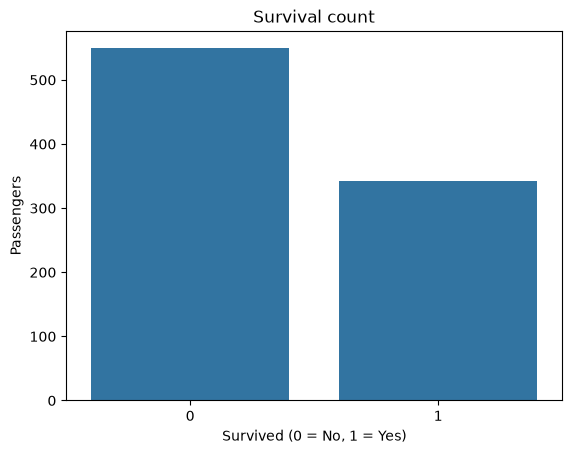

In [17]:
# 전체 생존/비생존 인원은 어떻게 분포하는가?
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df_work, x="Survived")
plt.title("Survival count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Passengers")
plt.show()

관찰:

해석:

추가 확인:

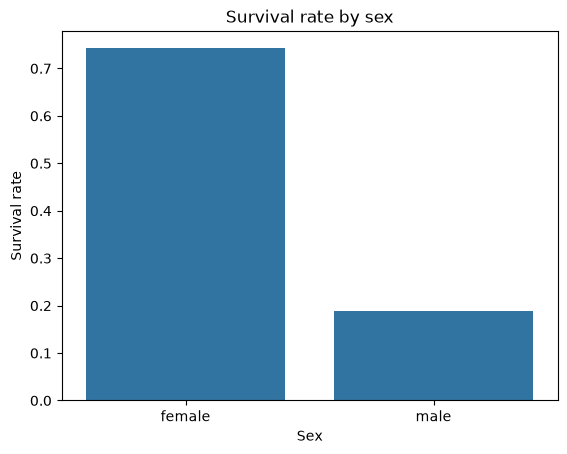

In [18]:
# 성별에 따라 생존율이 다른가?
sex_survival = (
    df_work.groupby("Sex", as_index=False)["Survived"]
    .mean()
)

sns.barplot(data=sex_survival, x="Sex", y="Survived")
plt.title("Survival rate by sex")
plt.ylabel("Survival rate")
plt.show()

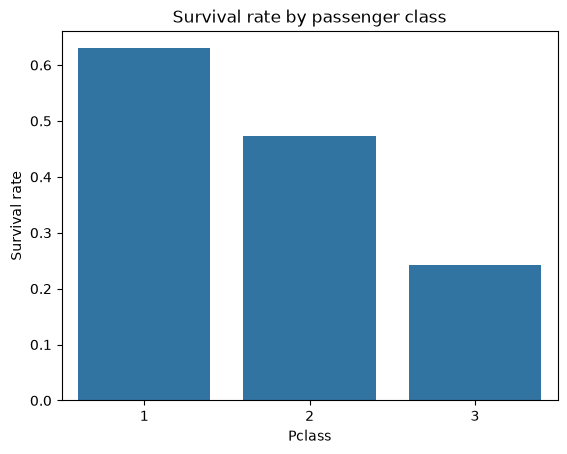

In [19]:
# 3. 객실 등급에 따라 생존율이 다른가?
pclass_survival = (
    df_work.groupby("Pclass", as_index=False)["Survived"]
    .mean()
)

sns.barplot(data=pclass_survival, x="Pclass", y="Survived")
plt.title("Survival rate by passenger class")
plt.ylabel("Survival rate")
plt.show()

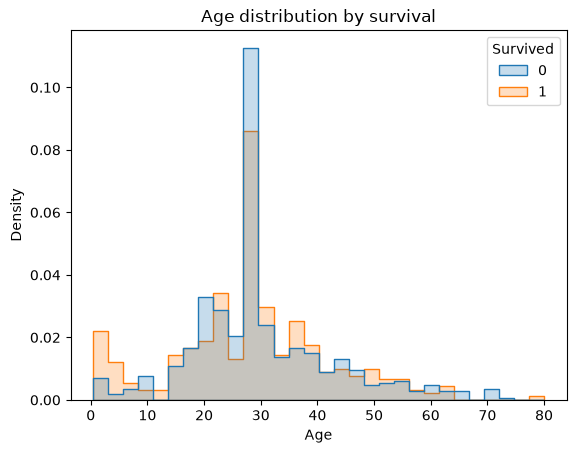

In [20]:
# 4. 나이와 생존 사이에 어떤 패턴이 보이는가?
sns.histplot(
    data=df_work,
    x="Age",
    hue="Survived",
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
)

plt.title("Age distribution by survival")
plt.show()

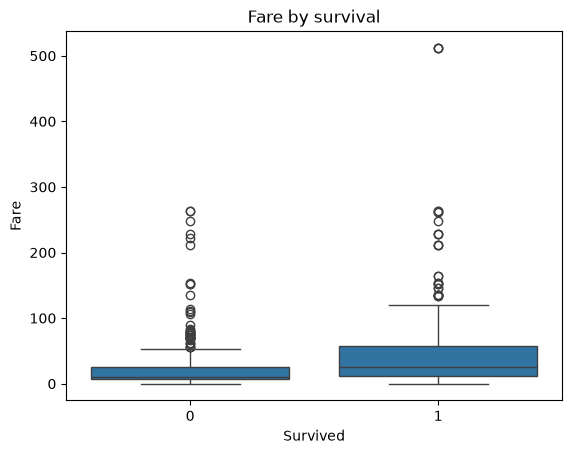

In [21]:
#  5. Fare와 생존 사이에 어떤 패턴이 보이는가?
sns.boxplot(data=df_work, x="Survived", y="Fare")
plt.title("Fare by survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

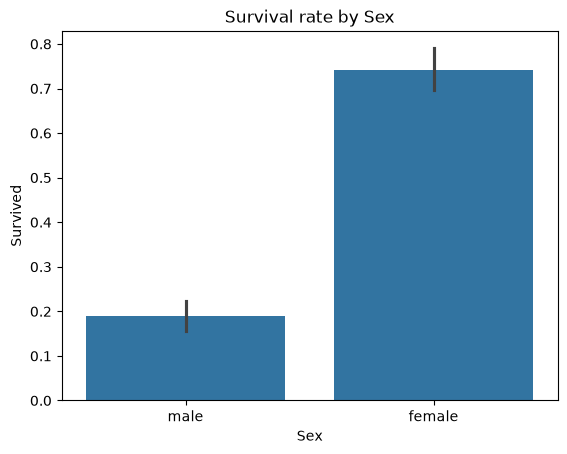

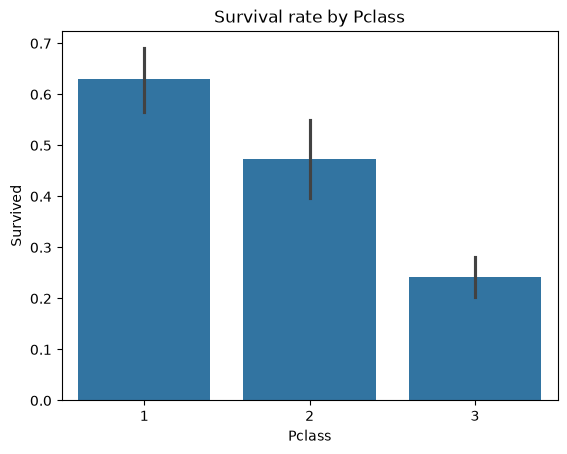

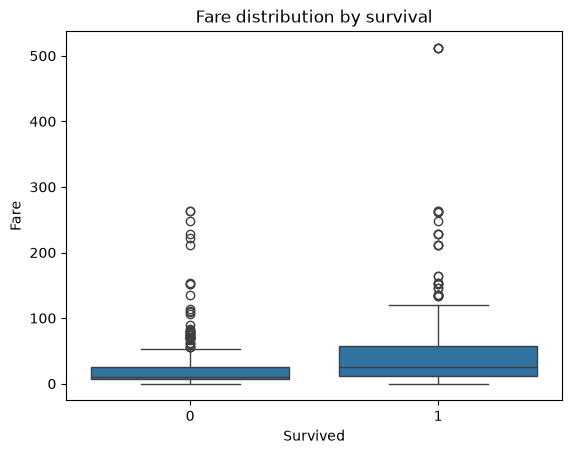

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots()
sns.barplot(data=df_work, x="Sex", y="Survived", ax=ax)
ax.set_title("Survival rate by Sex")
plt.show()
fig, ax = plt.subplots()
sns.barplot(data=df_work, x="Pclass", y="Survived", ax=ax)
ax.set_title("Survival rate by Pclass")
plt.show()
fig, ax = plt.subplots()
sns.boxplot(data=df_work, x="Survived", y="Fare", ax=ax)
ax.set_title("Fare distribution by survival")
ax.set_xlabel("Survived")
ax.set_ylabel("Fare")
plt.show()

In [23]:
display(df_work.groupby("Sex").agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))

display(df_work.groupby("Pclass").agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))

display(df_work.groupby(["Sex", "Pclass"]).agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))

,rows,survival_rate
Sex,,
female,314,0.742038
male,577,0.188908


,rows,survival_rate
Pclass,,
1,216,0.629630
2,184,0.472826
3,491,0.242363


rows  survival_rate
Sex    Pclass                     
female 1         94       0.968085
       2         76       0.921053
       3        144       0.500000
male   1        122       0.368852
       2        108       0.157407
       3        347       0.135447

In [24]:
from scipy import stats

survived = df_work.loc[df_work["Survived"] == 1, "Fare"]
not_survived = df_work.loc[df_work["Survived"] == 0, "Fare"]
t_stat, p_value = stats.ttest_ind(survived, not_survived, equal_var=False)

print("survived Fare mean:", round(survived.mean(), 2), " n =", survived.shape[0])
print("not survived Fare mean:", round(not_survived.mean(), 2), " n =", not_survived.shape[0])
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.3e}")

survived Fare mean: 48.4  n = 342
not survived Fare mean: 22.12  n = 549
t-statistic: 6.8391
p-value: 2.699e-11


In [25]:
feature_demo = df_work.copy()
feature_demo["FamilySize"] = feature_demo["SibSp"] + feature_demo["Parch"] + 1
feature_demo["IsAlone"] = (feature_demo["FamilySize"] == 1).astype(int)
display(feature_demo[["SibSp", "Parch", "FamilySize", "IsAlone", "Survived"]].head())

,SibSp,Parch,FamilySize,IsAlone,Survived
0,1,0,2,0,0
1,1,0,2,0,1
2,0,0,1,1,1
3,1,0,2,0,1
4,0,0,1,1,0


| 컬럼명 | 설명 | 비고 및 세부 값 |
| :--- | :--- | :--- |
| **PassengerId** | 승객 고유 ID | 승객에게 부여된 고유 식별 번호 |
| **Name** | 승객 이름 | 승객의 풀네임 (칭호 포함: Mr, Mrs, Miss 등) |
| **Sex** | 성별 | `male` (남성), `female` (여성) |
| **Age** | 나이 | 승객의 나이 (소수점 포함 가능) |
| **Pclass** | 티켓 등급 | 승객의 사회·경제적 지위를 나타냄<br>• `1`: 1등석<br>• `2`: 2등석<br>• `3`: 3등석 |
| **Ticket** | 티켓 번호 | 티켓의 고유 문자/숫자 조합 |
| **Fare** | 탑승 요금 | 지불한 운임 요금 |
| **Cabin** | 객실 번호 | 승객이 머문 구역 및 객실 번호 |
| **Embarked** | 탑승 항구 | 승객이 배에 탑승한 항구 위치<br>• `C`: Cherbourg (쉘부르)<br>• `Q`: Queenstown (퀸스타운)<br>• `S`: Southampton (사우스햄튼) |
| **SibSp** | 형제자매 / 배우자 수 | 함께 탑승한 형제, 자매, 배우자의 총합 |
| **Parch** | 부모 / 자녀 수 | 함께 탑승한 부모, 자녀의 총합 |
| **FamilySize** | 전체 가족 수 | 본인을 포함한 전체 가족 구성원 수<br>👉 **계산식:** `SibSp + Parch + 1` |
| **IsAlone** | 혼자 탑승 여부 | 동승자 없이 단독으로 탑승했는지 여부<br>• `1` (True): 혼자 탑승<br>• `0` (False): 가족/동승자 있음 |
| 컬럼명 | 설명 | 세부 값 |
| :--- | :--- | :--- |
| **Survived** | 생존 여부 | 승객의 최종 생존 결과<br>• `1`: 생존 (Survived)<br>• `0`: 사망 (Died) |

In [26]:
model_source = feature_demo.copy()

In [27]:
model_source.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     891 non-null    str    
 12  FamilySize   891 non-null    int64  
 13  IsAlone      891 non-null    int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 97.6 KB


In [28]:
feature_columns = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
]

In [29]:
model_source[feature_columns].head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,3,male,22.0,1,0,7.2500,S,2,0
1,1,female,38.0,1,0,71.2833,C,2,0
2,3,female,26.0,0,0,7.9250,S,1,1
3,1,female,35.0,1,0,53.1000,S,2,0
4,3,male,35.0,0,0,8.0500,S,1,1


model_source를 x로 카피하고

feature에는 정답을 뺀다.

servived를 y에 넣고

In [30]:
X = model_source[feature_columns].copy()
y = model_source["Survived"].astype(int).copy()

print("X:", X.shape)
print("y:", y.shape)

display(X.head())
display(y.head())

X: (891, 9)
y: (891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,3,male,22.0,1,0,7.2500,S,2,0
1,1,female,38.0,1,0,71.2833,C,2,0
2,3,female,26.0,0,0,7.9250,S,1,1
3,1,female,35.0,1,0,53.1000,S,2,0
4,3,male,35.0,0,0,8.0500,S,1,1


0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)
print("train:", X_train.shape, y_train.shape)
print("test :", X_test.shape, y_test.shape)

train: (712, 9) (712,)
test : (179, 9) (179,)


In [32]:
print("전체 데이터")
display(
    y.value_counts(normalize=True)
     .sort_index()
     .rename("ratio")
     .to_frame()
)

print("학습 데이터")
display(
    y_train.value_counts(normalize=True)
           .sort_index()
           .rename("train_ratio")
           .to_frame()
)

print("테스트 데이터")
display(
    y_test.value_counts(normalize=True)
          .sort_index()
          .rename("test_ratio")
          .to_frame()
)

전체 데이터


,ratio
Survived,
0,0.616162
1,0.383838


학습 데이터


,train_ratio
Survived,
0,0.616573
1,0.383427


테스트 데이터


,test_ratio
Survived,
0,0.614525
1,0.385475


In [33]:

raw_input_columns = [
    "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"
]

feature_columns = raw_input_columns + ["FamilySize", "IsAlone"]

numeric_features = [
    "Age", "SibSp", "Parch", "Fare", "FamilySize"
]

categorical_features = [
    "Pclass", "Sex", "Embarked", "IsAlone"
]

In [34]:
X = model_source[feature_columns].copy()

y = model_source["Survived"].astype(int).copy()

11-4. Train/Test 분리

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

STEP 12-1. 숫자형 결측치 처리

In [36]:

from sklearn.impute import SimpleImputer

numeric_imputer = SimpleImputer(strategy="median")

X_train_num_imputed = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[numeric_features]),
    columns=numeric_features,
    index=X_train.index,
)

X_test_num_imputed = pd.DataFrame(
    numeric_imputer.transform(X_test[numeric_features]),
    columns=numeric_features,
    index=X_test.index,
)

STEP 12-2. 범주형 결측치 처리

In [37]:

categorical_imputer = SimpleImputer(strategy="most_frequent")

X_train_cat_imputed = pd.DataFrame(

    categorical_imputer.fit_transform(X_train[categorical_features]),

    columns=categorical_features,

    index=X_train.index,

)

X_test_cat_imputed = pd.DataFrame(

    categorical_imputer.transform(X_test[categorical_features]),

    columns=categorical_features,

    index=X_test.index,

)

STEP 12-3. One-Hot Encoding

In [38]:

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(

    handle_unknown="ignore",

    sparse_output=False,

)

X_train_cat_encoded_array = encoder.fit_transform(X_train_cat_imputed)

X_test_cat_encoded_array = encoder.transform(X_test_cat_imputed)

encoded_feature_names = encoder.get_feature_names_out(categorical_features)

X_train_cat_encoded = pd.DataFrame(

    X_train_cat_encoded_array,

    columns=encoded_feature_names,

    index=X_train.index,

)

X_test_cat_encoded = pd.DataFrame(

    X_test_cat_encoded_array,

    columns=encoded_feature_names,

    index=X_test.index,

)

STEP 12-4. 정규화와 표준화 구분

In [39]:
from sklearn.preprocessing import MinMaxScaler

minmax_demo = MinMaxScaler()

minmax_preview = pd.DataFrame(

    minmax_demo.fit_transform(

        X_train_num_imputed[["Age", "Fare"]]

    ),

    columns=["Age_minmax", "Fare_minmax"],

    index=X_train.index,

)

display(minmax_preview.head())

,Age_minmax,Fare_minmax
692,0.346569,0.110272
481,0.346569,0.000000
527,0.346569,0.432884
855,0.220910,0.018250
801,0.384267,0.051237


STEP 12-5. StandardScaler로 실제 표준화

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num_scaled = pd.DataFrame(

    scaler.fit_transform(X_train_num_imputed),

    columns=numeric_features,

    index=X_train.index,

)

X_test_num_scaled = pd.DataFrame(

    scaler.transform(X_test_num_imputed),

    columns=numeric_features,

    index=X_test.index,

)

STEP 12-6. 숫자형과 범주형 데이터 결합

In [41]:

X_train_ready = pd.concat(

    [X_train_num_scaled, X_train_cat_encoded],

    axis=1,

)

X_test_ready = pd.concat(

    [X_test_num_scaled, X_test_cat_encoded],

    axis=1,

)

In [42]:
print("X_train_ready:", X_train_ready.shape)

print("X_test_ready :", X_test_ready.shape)

print("missing train:", X_train_ready.isna().sum().sum())

print("missing test :", X_test_ready.isna().sum().sum())

X_train_ready: (712, 15)
X_test_ready : (179, 15)
missing train: 0
missing test : 0


STEP 12-7. Logistic Regression Baseline 학습

머신러닝 모델(알고리즘이라고도 함)

In [43]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

baseline_model.fit(X_train_ready, y_train)

LogisticRegression(max_iter=1000, random_state=42)

STEP 13. 성능 평가와 Confusion Matrix

In [44]:

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

baseline_pred = baseline_model.predict(X_test_ready)
print("accuracy :", round(accuracy_score(y_test, baseline_pred), 4))
print("precision:", round(precision_score(y_test, baseline_pred), 4))
print("recall   :", round(recall_score(y_test, baseline_pred), 4))
print("f1       :", round(f1_score(y_test, baseline_pred), 4))

accuracy : 0.8156
precision: 0.8103
recall   : 0.6812
f1       : 0.7402


In [46]:
cm = confusion_matrix(y_test, baseline_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(cm)
print({"TN": tn, "FP": fp, "FN": fn, "TP": tp})

[[99 11]
 [22 47]]
{'TN': np.int64(99), 'FP': np.int64(11), 'FN': np.int64(22), 'TP': np.int64(47)}


STEP 14. 추가 모델 — Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

additional_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

additional_model.fit(X_train_ready, y_train)

additional_pred = additional_model.predict(X_test_ready)

STEP 15. 모델 비교와 최종 선택

In [49]:
model_compare = pd.DataFrame([

    {

        "model": "Logistic Regression",

        "accuracy": accuracy_score(y_test, baseline_pred),

        "f1": f1_score(y_test, baseline_pred),

    },

    {

        "model": "Random Forest",

        "accuracy": accuracy_score(y_test, additional_pred),

        "f1": f1_score(y_test, additional_pred),

    },

])

display(model_compare)

,model,accuracy,f1
0,Logistic Regression,0.815642,0.740157
1,Random Forest,0.821229,0.741935


In [50]:
FINAL_MODEL_CHOICE = "baseline"

if FINAL_MODEL_CHOICE == "baseline":
    final_model = baseline_model
    final_model_name = "Logistic Regression"
elif FINAL_MODEL_CHOICE == "random_forest":
    final_model = additional_model
    final_model_name = "Random Forest"
else:

    raise ValueError("baseline 또는 random_forest를 선택하세요.")

## Part 3. 저장·새 입력 예측·서비스

STEP 16–17

STEP 16. 전처리 객체와 모델 저장

In [51]:
import json

import joblib

models_dir = project_root / "models"

models_dir.mkdir(parents=True, exist_ok=True)

bundle_path = models_dir / "titanic_model_bundle.joblib"

contract_path = models_dir / "titanic_model_contract.json"

model_bundle = {
    "numeric_imputer": numeric_imputer,
    "categorical_imputer": categorical_imputer,
    "encoder": encoder,
    "scaler": scaler,
    "model": final_model,
}

joblib.dump(model_bundle, bundle_path)

['C:\\Dev\\llm-data-analysis\\models\\titanic_model_bundle.joblib']

In [52]:
model_contract = {
    "task": "binary_classification",
    "target": "Survived",
    "positive_class": 1,
    "raw_input_columns": raw_input_columns,
    "model_feature_columns": feature_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "prepared_feature_columns": X_train_ready.columns.tolist(),
    "derived_features": ["FamilySize", "IsAlone"],
    "scaling": "StandardScaler",
    "final_estimator": type(final_model).__name__,
}

In [58]:
import json
from pathlib import Path

project_root = Path.cwd()

# Notebook을 notebooks 폴더에서 실행하는 경우
if project_root.name == "notebooks":
    project_root = project_root.parent

contract_path = project_root / "models" / "titanic_model_contract.json"

contract_path.parent.mkdir(parents=True, exist_ok=True)

contract_path.write_text(
    json.dumps(
        model_contract,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)


print("Contract 저장 완료:")
print(contract_path.resolve())
print("파일 존재:", contract_path.exists())

Contract 저장 완료:
C:\Dev\llm-data-analysis\models\titanic_model_contract.json
파일 존재: True


In [53]:
loaded_bundle = joblib.load(bundle_path)
new_passenger = pd.DataFrame([{
    "Pclass": 3,
    "Sex": "male",
    "Age": 30.0,
    "SibSp": 0,
    "Parch": 0,
    "Fare": 10.0,
    "Embarked": "S",
}])

In [54]:
new_passenger["FamilySize"] = (
    new_passenger["SibSp"] + new_passenger["Parch"] + 1
)

new_passenger["IsAlone"] = (
    new_passenger["FamilySize"] == 1
).astype(int)

In [55]:
new_num_imputed = loaded_bundle["numeric_imputer"].transform(
    new_passenger[numeric_features]
)
new_num_scaled = loaded_bundle["scaler"].transform(new_num_imputed)

new_cat_imputed = loaded_bundle["categorical_imputer"].transform(
    new_passenger[categorical_features]
)
new_cat_encoded = loaded_bundle["encoder"].transform(new_cat_imputed)

new_ready = pd.DataFrame(
    np.hstack([new_num_scaled, new_cat_encoded]),
    columns=model_contract["prepared_feature_columns"],
)

c:\Dev\llm-data-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Dev\llm-data-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [57]:
loaded_model = loaded_bundle["model"]
new_prediction = int(loaded_model.predict(new_ready)[0])
positive_index = list(loaded_model.classes_).index(1)
positive_probability = float(
    loaded_model.predict_proba(new_ready)[0][positive_index]
)

print(new_prediction)

0
